# Pick the chart from the question

The chart type is not a preference. It is the encoding the question asks for.

| Question | Mark |
|---|---|
| How much, across names? | Bar length, from zero |
| What changed across an ordered time? | Line |
| How is a pile of values spread? | Histogram, with bins you state |
| Where do two measurements sit together? | Scatter, unjoined |
| What is in each cell of a table? | Heatmap, with the number still printed if the table is small |

North Lab can answer three of these without any new arithmetic. The weekly ranking is the bars. The daily speedup is the line. The person-by-day table is the heatmap. Using one of those pictures to answer a different question is how a correct data set grows a wrong sentence.


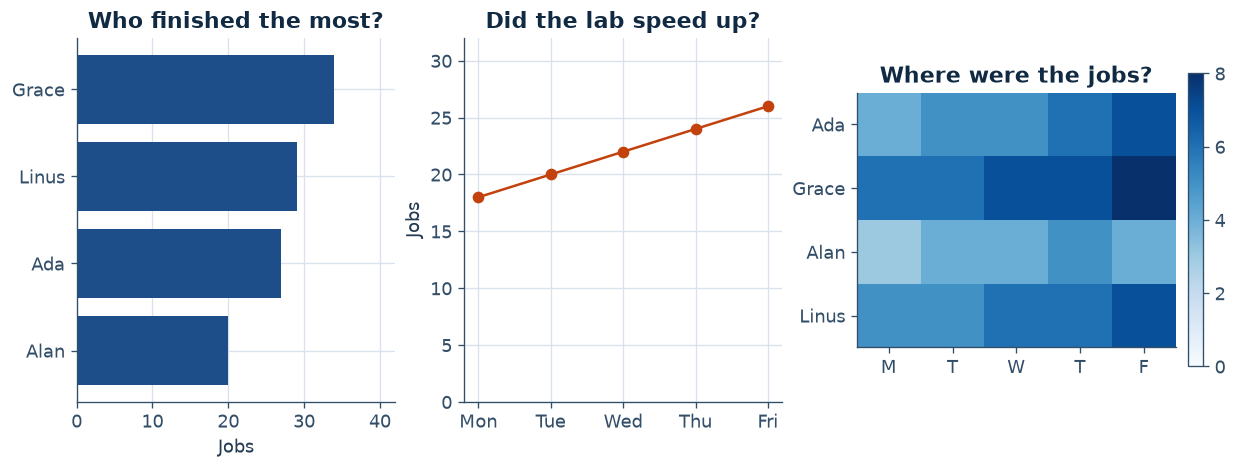

In [1]:
import matplotlib.pyplot as plt

# Quiet page: data ink first, grid behind the marks, colors that stay distinct.
plt.rcParams.update({
    "figure.figsize": (7.2, 4.2),
    "figure.dpi": 120,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": "#d9e2ec",
    "axes.edgecolor": "#334e68",
    "axes.labelcolor": "#243b53",
    "xtick.color": "#334e68",
    "ytick.color": "#334e68",
    "text.color": "#102a43",
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "font.size": 11,
    "savefig.facecolor": "white",
})
BLUE = "#1d4e89"
CLAY = "#c2410c"
GREEN = "#0f766e"
INK = "#102a43"
GRAY = "#9fb3c8"
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=[BLUE, CLAY, GREEN])

# Three questions, three encodings, one page.
fig, panels = plt.subplots(1, 3, constrained_layout=True, figsize=(10.2, 3.8))
panels[0].barh(["Alan", "Ada", "Linus", "Grace"], [20, 27, 29, 34], color=BLUE)
panels[0].set_xlim(0, 42)
panels[0].set_xlabel("Jobs")
panels[0].set_title("Who finished the most?")
panels[1].plot(["Mon", "Tue", "Wed", "Thu", "Fri"], [18, 20, 22, 24, 26], color=CLAY, marker="o")
panels[1].set_ylim(0, 32)
panels[1].set_ylabel("Jobs")
panels[1].set_title("Did the lab speed up?")
jobs = [
    [4, 5, 5, 6, 7],
    [6, 6, 7, 7, 8],
    [3, 4, 4, 5, 4],
    [5, 5, 6, 6, 7],
]
image = panels[2].imshow(jobs, cmap="Blues", vmin=0, vmax=8)
panels[2].set_xticks(range(5), ["M", "T", "W", "T", "F"])
panels[2].set_yticks(range(4), ["Ada", "Grace", "Alan", "Linus"])
panels[2].grid(False)
panels[2].set_title("Where were the jobs?")
fig.colorbar(image, ax=panels[2], fraction=0.046, pad=0.04)
assert len(panels[0].patches) == 4
assert len(panels[1].lines) == 1


## Hours against jobs is not a bar chart

Ada $30$ hours and $27$ jobs, Grace $32$ and $34$, Alan $30$ and $20$, Linus $31$ and $29$. The question is how the two measurements sit together. A bar of the hours and a bar of the jobs would make you compare lengths in your head. The scatter puts both measurements on the same dot. Alan remains the person who worked $30$ hours and finished $7$ fewer jobs than Ada.


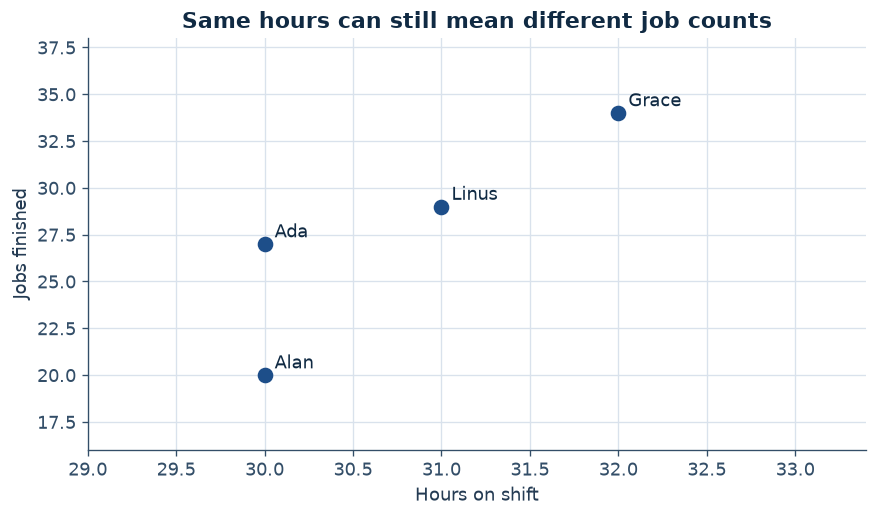

In [2]:
import matplotlib.pyplot as plt

# Quiet page: data ink first, grid behind the marks, colors that stay distinct.
plt.rcParams.update({
    "figure.figsize": (7.2, 4.2),
    "figure.dpi": 120,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "axes.axisbelow": True,
    "grid.color": "#d9e2ec",
    "axes.edgecolor": "#334e68",
    "axes.labelcolor": "#243b53",
    "xtick.color": "#334e68",
    "ytick.color": "#334e68",
    "text.color": "#102a43",
    "axes.titleweight": "bold",
    "axes.titlesize": 13,
    "axes.labelsize": 11,
    "font.size": 11,
    "savefig.facecolor": "white",
})
BLUE = "#1d4e89"
CLAY = "#c2410c"
GREEN = "#0f766e"
INK = "#102a43"
GRAY = "#9fb3c8"
plt.rcParams["axes.prop_cycle"] = plt.cycler(color=[BLUE, CLAY, GREEN])

# Scatter, because the question is the pair, not a ranking of one column.
names = ["Ada", "Grace", "Alan", "Linus"]
hours = [30, 32, 30, 31]
jobs = [27, 34, 20, 29]
fig, ax = plt.subplots(constrained_layout=True)
ax.scatter(hours, jobs, s=70, color=BLUE, zorder=3)
for name, x, y in zip(names, hours, jobs):
    ax.annotate(name, (x, y), textcoords="offset points", xytext=(6, 4), color=INK)
ax.set_xlabel("Hours on shift")
ax.set_ylabel("Jobs finished")
ax.set_xlim(29, 33.4)
ax.set_ylim(16, 38)
ax.set_title("Same hours can still mean different job counts")


## A pitfall

The chart you can draw fastest is not the chart the question asked for. A line through Alan, Ada, Linus, and Grace is quick and still answers "who" badly, because it invents an order. Write the question at the top of the page before you write the plotting call.

## What to carry forward

Bars compare names. Lines follow time. Scatters hold a pair. Heatmaps hold a grid. The lab's three answers stay what they were: Grace, two jobs a day, and a Friday cell of $8$.
